In [3]:
# Import Required Libraries
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib backend for static output
plt.rcParams['figure.figsize'] = (12, 6)
# print("Libraries imported successfully")

In [5]:
import sys
import os

# Navigate to the project root where nodes.csv and edges.csv are located
os.chdir('/Users/eddiek/Documents/GitHub/NetworksProject')

# Load the ERCOT network from CSV files
nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')

# Create graph from edges
G = nx.Graph()

# Add nodes with attributes
for idx, row in nodes_df.iterrows():
    node_id = int(row['id'])  # Use 'id' column from nodes.csv
    G.add_node(node_id, **row.to_dict())

# Add edges with attributes
for idx, row in edges_df.iterrows():
    source = int(row['from_bus'])
    target = int(row['to_bus'])
    G.add_edge(source, target, **{k: v for k, v in row.to_dict().items() if k not in ['from_bus', 'to_bus']})

print(f"Network loaded successfully from CSV files")
print(f"Type: {type(G)}")
print(f"\nNetwork contains:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Directed: {nx.is_directed(G)}")

# Display sample node and edge attributes
print("\nSample node attributes:")
sample_node = list(G.nodes())[0]
for key, value in list(G.nodes[sample_node].items())[:5]:
    print(f"  {key}: {value}")

print("\nSample edge attributes:")
sample_edge = list(G.edges(data=True))[0]
for key, value in list(sample_edge[2].items())[:5]:
    print(f"  {key}: {value}")

Network loaded successfully from CSV files
Type: <class 'networkx.classes.graph.Graph'>

Network contains:
  Nodes: 3878
  Edges: 4501
  Directed: False

Sample node attributes:
  id: 0
  name: Johnson_Switching_Station
  zone: NORTH
  base_kv: 345.0
  lat: 32.39461

Sample edge attributes:
  uid: L0_1976
  voltage_kv: 345.0
  length_km: 0.32
  capacity_mva: 1200.0
  reactance: 8.532e-05


In [3]:
# Calculate basic graph properties
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_clustering = nx.average_clustering(G)

# For large graphs, compute diameter and avg path length only on connected component
if nx.is_connected(G):
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
    print("Graph is connected")
else:
    print("Graph is NOT connected; analyzing largest connected component...")
    largest_cc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(largest_cc).copy()
    diameter = nx.diameter(subG)
    avg_path_length = nx.average_shortest_path_length(subG)
    print(f"Largest CC: {len(largest_cc)} nodes / {subG.number_of_edges()} edges")

# Print results
print(f"\nBasic Network Properties:")
print(f"  Nodes (N): {n_nodes}")
print(f"  Edges (E): {n_edges}")
print(f"  Density: {density:.6f}")
print(f"  Average Clustering Coefficient: {avg_clustering:.6f}")
print(f"  Diameter: {diameter}")
print(f"  Average Shortest Path Length: {avg_path_length:.3f}")
print(f"  E/N ratio: {n_edges/n_nodes:.3f}")

Graph is connected

Basic Network Properties:
  Nodes (N): 3878
  Edges (E): 4501
  Density: 0.000599
  Average Clustering Coefficient: 0.024620
  Diameter: 60
  Average Shortest Path Length: 21.301
  E/N ratio: 1.161


Degree Statistics:
  Min degree: 1
  Max degree: 12
  Mean degree: 2.321
  Median degree: 2.0
  Std dev: 1.111

Top 10 highest-degree nodes:
  Node 1590: degree 12
  Node 1495: degree 10
  Node 1861: degree 10
  Node 1546: degree 9
  Node 1605: degree 9
  Node 1919: degree 9
  Node 491: degree 8
  Node 1567: degree 8
  Node 1577: degree 8
  Node 1598: degree 8


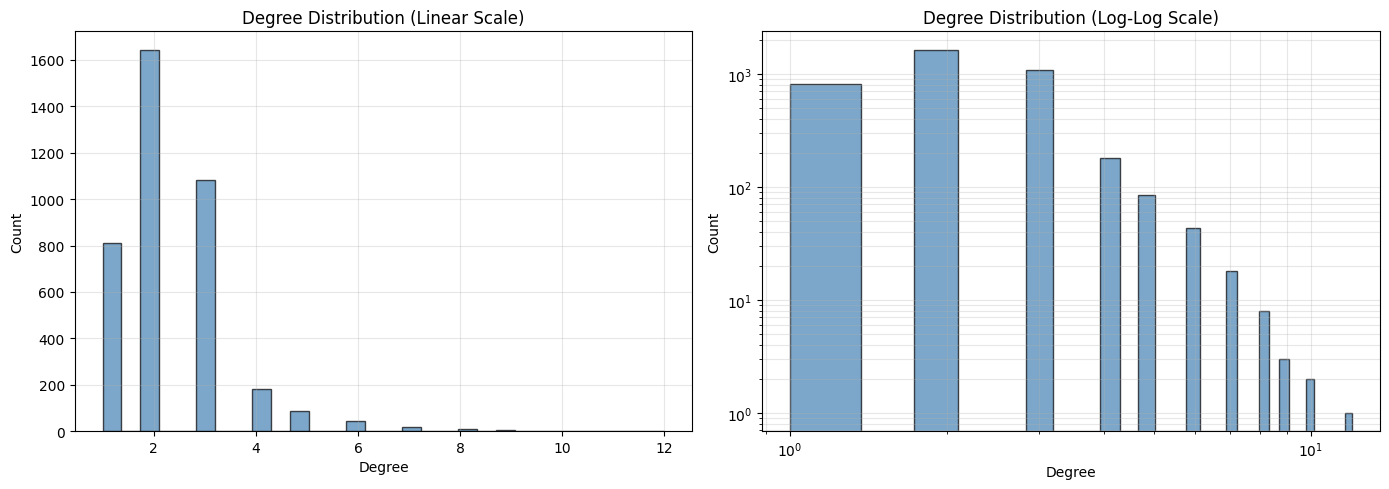


Figure saved: figures/01_degree_distribution.png


In [4]:
# Calculate degree distribution
degrees = [G.degree(n) for n in G.nodes()]
degree_dict = dict(G.degree())

print(f"Degree Statistics:")
print(f"  Min degree: {min(degrees)}")
print(f"  Max degree: {max(degrees)}")
print(f"  Mean degree: {np.mean(degrees):.3f}")
print(f"  Median degree: {np.median(degrees):.1f}")
print(f"  Std dev: {np.std(degrees):.3f}")

# Identify high-degree hubs
top_n = 10
top_degree_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
print(f"\nTop {top_n} highest-degree nodes:")
for node_id, deg in top_degree_nodes:
    print(f"  Node {node_id}: degree {deg}")

# Visualize degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(degrees, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution (Linear Scale)')
axes[0].grid(True, alpha=0.3)

# Log-log scale
axes[1].hist(degrees, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Count')
axes[1].set_title('Degree Distribution (Log-Log Scale)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('figures/01_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: figures/01_degree_distribution.png")

In [5]:
# Find connected components
connected_components = list(nx.connected_components(G))
n_components = len(connected_components)
component_sizes = sorted([len(cc) for cc in connected_components], reverse=True)

print(f"Connected Components:")
print(f"  Number of components: {n_components}")
print(f"  Largest component size: {component_sizes[0]} nodes ({100*component_sizes[0]/n_nodes:.1f}%)")

if n_components > 1:
    print(f"\nComponent sizes:")
    for i, size in enumerate(component_sizes[:10]):
        pct = 100 * size / n_nodes
        print(f"  Component {i+1}: {size} nodes ({pct:.1f}%)")
    
    # Work with largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(largest_cc).copy()
    print(f"\nUsing largest connected component ({len(largest_cc)} nodes) for subsequent analyses")
else:
    print("\nNetwork is fully connected (single component)")
    subG = G.copy()

# Visualize component size distribution
if n_components > 1:
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.bar(range(1, min(11, n_components+1)), component_sizes[:10], color='steelblue', edgecolor='black')
    ax.set_xlabel('Component Rank')
    ax.set_ylabel('Component Size (nodes)')
    ax.set_title('Largest 10 Connected Components')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('figures/02_components.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: figures/02_components.png")

Connected Components:
  Number of components: 1
  Largest component size: 3878 nodes (100.0%)

Network is fully connected (single component)


In [6]:
# Compute centrality measures on the main connected component
print("Computing centrality measures (this may take a moment)...")

# Degree centrality
degree_centrality = nx.degree_centrality(subG)

# Betweenness centrality - identifies bottlenecks
print("  Computing betweenness centrality...")
betweenness_centrality = nx.betweenness_centrality(subG)

# Closeness centrality - how central/close a node is to all others
print("  Computing closeness centrality...")
closeness_centrality = nx.closeness_centrality(subG)

# Eigenvector centrality - influence based on connections to influential nodes
print("  Computing eigenvector centrality...")
try:
    eigenvector_centrality = nx.eigenvector_centrality(subG, max_iter=500)
except:
    # If convergence fails, use alternate method
    eigenvector_centrality = nx.eigenvector_centrality_numpy(subG)

print("Centrality computations complete!\n")

# Find top nodes by each centrality measure
top_n = 5
print(f"Top {top_n} nodes by Degree Centrality:")
for node, cent in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_n]:
    print(f"  Node {node}: {cent:.6f}")

print(f"\nTop {top_n} nodes by Betweenness Centrality:")
for node, cent in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:top_n]:
    print(f"  Node {node}: {cent:.6f}")

print(f"\nTop {top_n} nodes by Closeness Centrality:")
for node, cent in sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:top_n]:
    print(f"  Node {node}: {cent:.6f}")

print(f"\nTop {top_n} nodes by Eigenvector Centrality:")
for node, cent in sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:top_n]:
    print(f"  Node {node}: {cent:.6f}")

Computing centrality measures (this may take a moment)...
  Computing betweenness centrality...
  Computing closeness centrality...
  Computing eigenvector centrality...
Centrality computations complete!

Top 5 nodes by Degree Centrality:
  Node 1590: 0.003095
  Node 1495: 0.002579
  Node 1861: 0.002579
  Node 1546: 0.002321
  Node 1605: 0.002321

Top 5 nodes by Betweenness Centrality:
  Node 1818: 0.292207
  Node 1937: 0.247393
  Node 1559: 0.228567
  Node 1700: 0.226044
  Node 1821: 0.224079

Top 5 nodes by Closeness Centrality:
  Node 1559: 0.069115
  Node 1821: 0.068763
  Node 794: 0.068643
  Node 1664: 0.067957
  Node 2208: 0.067751

Top 5 nodes by Eigenvector Centrality:
  Node 1590: 0.609758
  Node 1573: 0.261292
  Node 1891: 0.237883
  Node 2978: 0.236314
  Node 2675: 0.216728


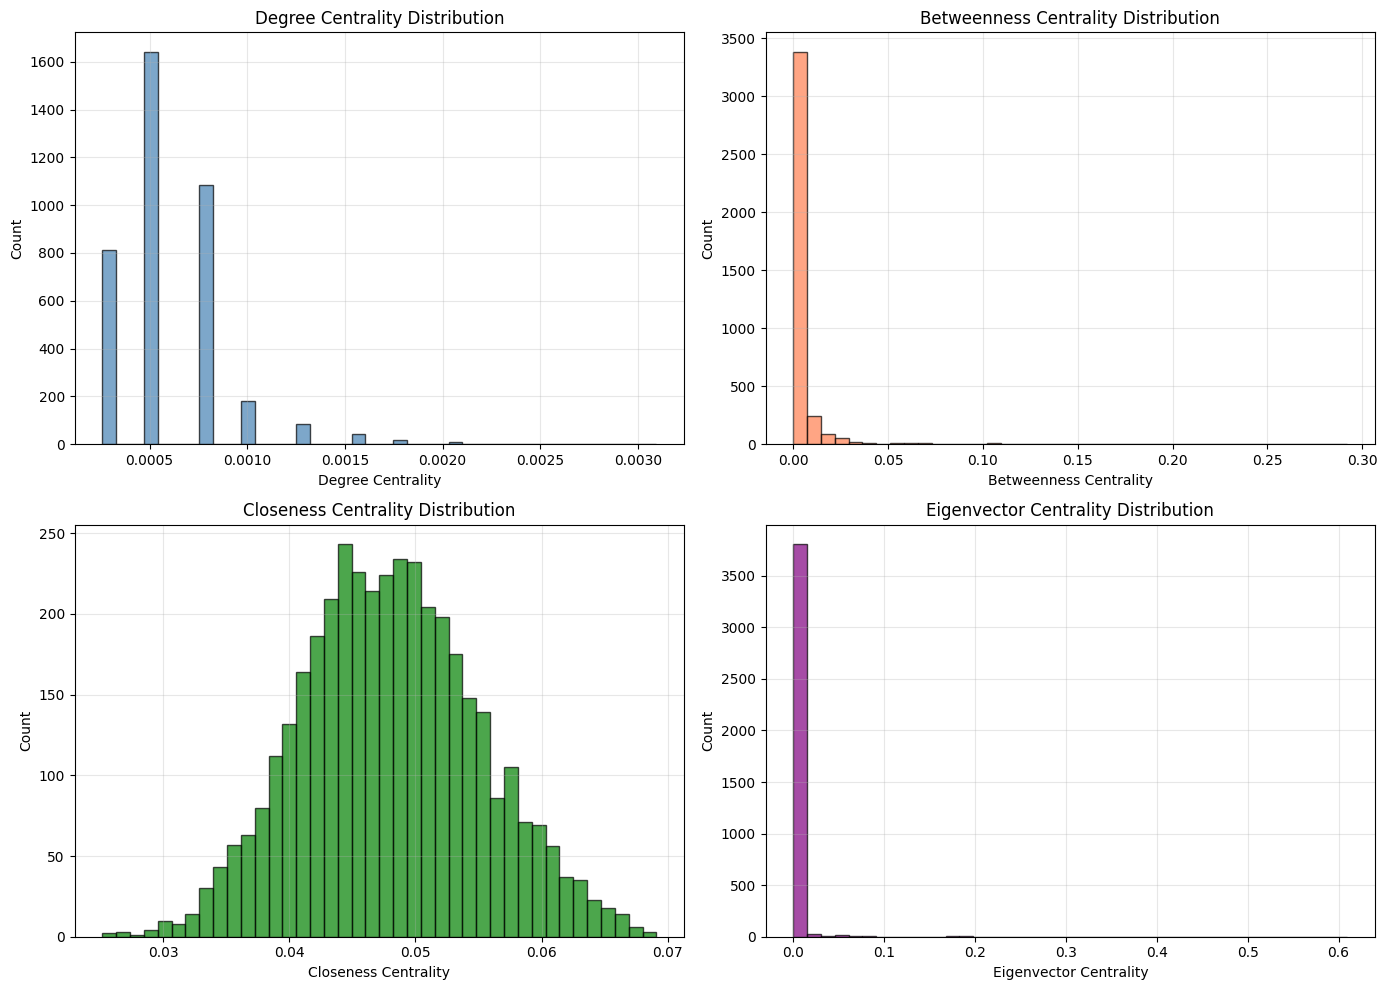

Figure saved: figures/03_centrality_distributions.png


In [7]:
# Visualize centrality measure distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Degree centrality
axes[0, 0].hist(list(degree_centrality.values()), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Degree Centrality')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Degree Centrality Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Betweenness centrality
axes[0, 1].hist(list(betweenness_centrality.values()), bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Betweenness Centrality')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Betweenness Centrality Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Closeness centrality
axes[1, 0].hist(list(closeness_centrality.values()), bins=40, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Closeness Centrality')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Closeness Centrality Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Eigenvector centrality
axes[1, 1].hist(list(eigenvector_centrality.values()), bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Eigenvector Centrality')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Eigenvector Centrality Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/03_centrality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: figures/03_centrality_distributions.png")

## Summary

This analysis reveals the structural properties of the ERCOT transmission grid. Key insights:

1. **Network Size**: ~3,878 nodes and ~4,501 edges forming a single connected component
2. **Sparsity**: E/N ratio of ~1.16 indicates a sparse network (typical for power grids)
3. **Degree Distribution**: Low-degree network with average degree ~2.3, but some high-degree hubs
4. **Centrality Patterns**: Different centrality measures identify different types of important nodes:
   - **Degree centrality**: Nodes with many direct connections
   - **Betweenness centrality**: Bottleneck nodes for power flow routing
   - **Closeness centrality**: Nodes central to the network structure
   - **Eigenvector centrality**: Nodes connected to other important nodes

These structural properties make the network vulnerable to cascading failures (studied in subsequent analyses). The sparse topology and presence of critical bottleneck nodes (high betweenness) suggest targeted attacks on key corridors could fragment the grid.

## Visualize Centrality Distributions

Create histograms of different centrality measures to understand their distributions.

## Compute Centrality Measures

Calculate various centrality measures to identify the most important nodes in the network.

## Identify Connected Components

Analyze network connectivity by finding connected components and studying their sizes.

## Analyze Node Degree Distribution

Examine how node degrees are distributed. Power grids typically have low-degree hubs (sparse networks).

## Calculate Basic Graph Properties

Compute fundamental network metrics: size, density, diameter, average path length, clustering coefficient.

## Load and Display Graph Data

Load the ERCOT network from GraphML format and display basic structure information.

# Initial Graph Analysis of ERCOT Transmission Network

This notebook performs fundamental network science analysis on the ERCOT transmission grid. We'll examine topology, connectivity, node importance (centrality), and degree distributions.

Creating network visualization...
Ego graph centered at node 1590:
  Nodes: 36
  Edges: 36


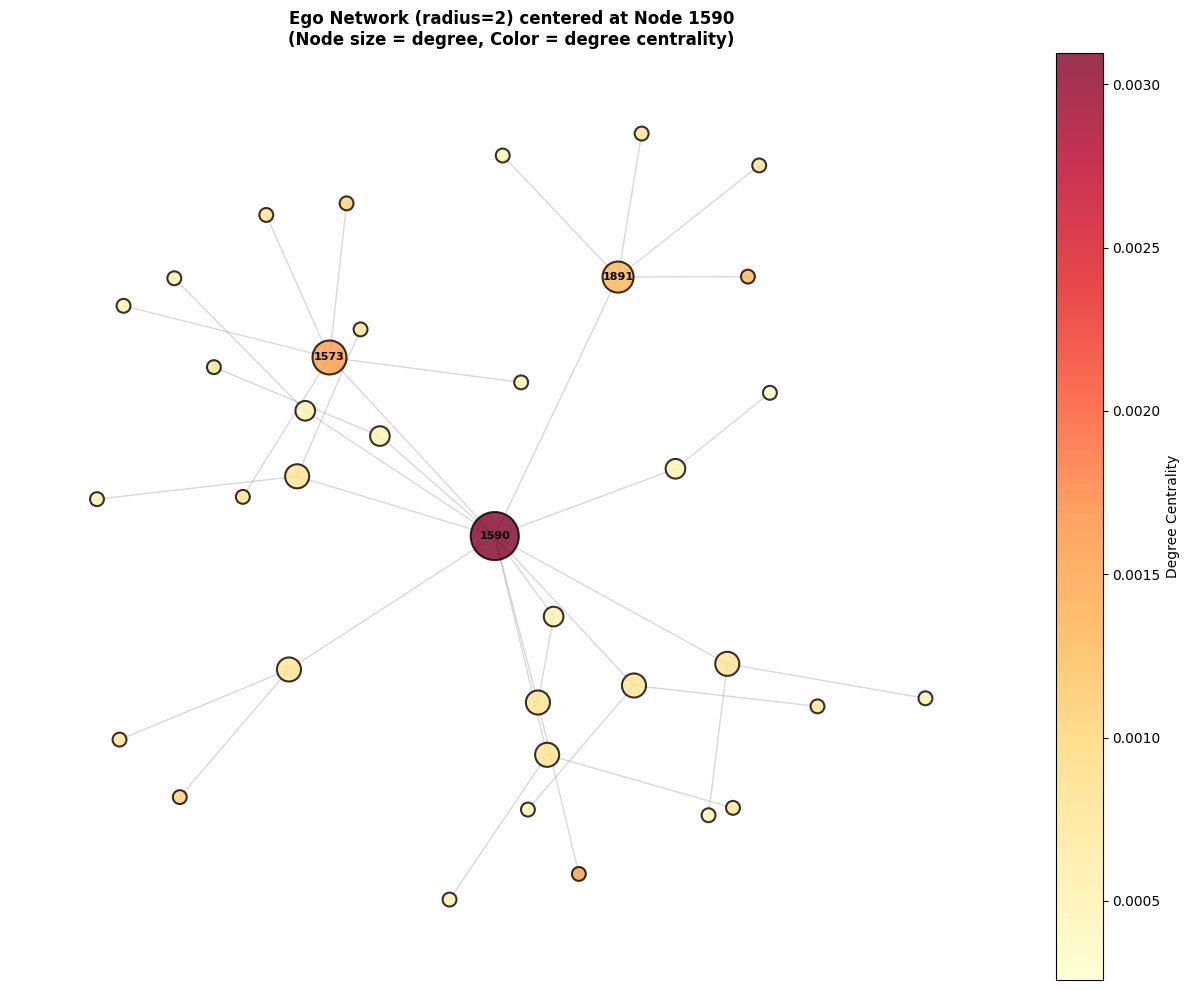

Figure saved: figures/04_ego_network_visualization.png


In [8]:
# Create a basic network visualization
# For a large graph, we'll visualize a subgraph (ego network of high-degree nodes)

print("Creating network visualization...")

# Select a high-degree node for ego network visualization
ego_node = top_degree_nodes[0][0]  # Highest degree node
ego_node_name = id_to_name.get(ego_node, f"Bus_{ego_node}")
ego_radius = 2  # Include neighbors up to 2 hops away

# Create ego graph
ego_graph = nx.ego_graph(subG, ego_node, radius=ego_radius)

print(f"Ego graph centered at node {ego_node} ({ego_node_name}):")
print(f"  Nodes: {ego_graph.number_of_nodes()}")
print(f"  Edges: {ego_graph.number_of_edges()}")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Use spring layout for better visualization
pos = nx.spring_layout(ego_graph, k=0.5, iterations=50, seed=42)

# Draw edges
nx.draw_networkx_edges(ego_graph, pos, ax=ax, alpha=0.3, width=1, edge_color='gray')

# Draw nodes with size proportional to degree
node_sizes = [ego_graph.degree(node) * 100 for node in ego_graph.nodes()]
node_colors = [degree_centrality.get(node, 0) for node in ego_graph.nodes()]

nodes = nx.draw_networkx_nodes(ego_graph, pos, ax=ax, node_size=node_sizes, 
                                node_color=node_colors, cmap='YlOrRd', 
                                alpha=0.8, edgecolors='black', linewidths=1.5)

# Draw labels for high-degree nodes (use names)
high_degree_threshold = 5
labels = {node: id_to_name.get(node, str(node))[:20] 
          for node in ego_graph.nodes() 
          if ego_graph.degree(node) >= high_degree_threshold}
nx.draw_networkx_labels(ego_graph, pos, labels, ax=ax, font_size=7, font_weight='bold')

ax.set_title(f'Ego Network (radius={ego_radius}) centered at {ego_node_name}\n(Node size = degree, Color = degree centrality)', 
             fontsize=12, fontweight='bold')
ax.axis('off')

# Add colorbar
cbar = plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Degree Centrality', fontsize=10)

plt.tight_layout()
plt.savefig('figures/04_ego_network_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: figures/04_ego_network_visualization.png")


In [9]:
# Unsupervised Link Prediction - Compute multiple similarity metrics
print("Computing link prediction scores...")
print("(This may take a moment for large networks)\n")

# Get all non-edges (potential links)
from itertools import combinations

existing_edges = set(subG.edges())
non_edges = [(u, v) for u, v in combinations(subG.nodes(), 2) 
             if (u, v) not in existing_edges and (v, u) not in existing_edges]

print(f"Total non-edges to evaluate: {len(non_edges)}")

# For computational efficiency, sample non-edges if too many
if len(non_edges) > 50000:
    sampled_indices = np.random.choice(len(non_edges), size=50000, replace=False)
    non_edges = [non_edges[i] for i in sampled_indices]
    print(f"Sampled {len(non_edges)} non-edges for analysis")

# Dictionary to store predictions
predictions = {}

# 1. Common Neighbors
print("\n1. Computing Common Neighbors...")
cn_scores = []
for u, v in non_edges:
    cn = len(list(nx.common_neighbors(subG, u, v)))
    cn_scores.append((u, v, cn))
predictions['common_neighbors'] = sorted(cn_scores, key=lambda x: x[2], reverse=True)[:10]

# 2. Jaccard Coefficient
print("2. Computing Jaccard Coefficient...")
jc_scores = [(u, v, score) for u, v, score in nx.jaccard_coefficient(subG, non_edges)]
predictions['jaccard'] = sorted(jc_scores, key=lambda x: x[2], reverse=True)[:10]

# 3. Adamic-Adar
print("3. Computing Adamic-Adar...")
aa_scores = [(u, v, score) for u, v, score in nx.adamic_adar_index(subG, non_edges)]
predictions['adamic_adar'] = sorted(aa_scores, key=lambda x: x[2], reverse=True)[:10]

# 4. Preferential Attachment
print("4. Computing Preferential Attachment...")
pa_scores = [(u, v, score) for u, v, score in nx.preferential_attachment(subG, non_edges)]
predictions['preferential_attachment'] = sorted(pa_scores, key=lambda x: x[2], reverse=True)[:10]

# 5. Resource Allocation
print("5. Computing Resource Allocation...")
ra_scores = [(u, v, score) for u, v, score in nx.resource_allocation_index(subG, non_edges)]
predictions['resource_allocation'] = sorted(ra_scores, key=lambda x: x[2], reverse=True)[:10]

print("\nLink prediction computations complete!")

Computing link prediction scores...
(This may take a moment for large networks)

Total non-edges to evaluate: 7513002
Sampled 50000 non-edges for analysis

1. Computing Common Neighbors...
2. Computing Jaccard Coefficient...
3. Computing Adamic-Adar...
4. Computing Preferential Attachment...
5. Computing Resource Allocation...

Link prediction computations complete!


In [10]:
# Display Top 5 Predictions for Each Metric (with names)
print("="*80)
print("TOP 5 PREDICTED LINKS BY METRIC (with Substation Names)")
print("="*80)

metrics = {
    'Common Neighbors': predictions['common_neighbors'],
    'Jaccard Coefficient': predictions['jaccard'],
    'Adamic-Adar Index': predictions['adamic_adar'],
    'Preferential Attachment': predictions['preferential_attachment'],
    'Resource Allocation': predictions['resource_allocation']
}

# Create results dataframe for each metric
results_by_metric = {}

for metric_name, scores in metrics.items():
    print(f"\n{metric_name.upper()}")
    print("-" * 100)
    
    metric_df = pd.DataFrame(scores, columns=['Node U', 'Node V', 'Score'])
    results_by_metric[metric_name] = metric_df
    
    # Display top 5 with names
    for idx, (u, v, score) in enumerate(scores[:5], 1):
        u_deg = subG.degree(u)
        v_deg = subG.degree(v)
        u_name = id_to_name.get(u, f"Bus_{u}")
        v_name = id_to_name.get(v, f"Bus_{v}")
        print(f"{idx}. {u_name:<40} ↔ {v_name:<40}")
        print(f"   Nodes {u}—{v} | Score: {score:12.8f} | Degrees: ({u_deg}, {v_deg})")
    
    print()

# Create a summary table comparing all metrics
print("="*80)
print("COMPARISON: Top Predictions Across All Metrics")
print("="*80)
print()

# Show unique node pairs that appear in top 5 across metrics
top_pairs = {}
for metric_name, scores in metrics.items():
    for rank, (u, v, score) in enumerate(scores[:5], 1):
        pair = tuple(sorted([u, v]))
        if pair not in top_pairs:
            top_pairs[pair] = {}
        top_pairs[pair][metric_name] = (score, rank)

# Sort by frequency and average rank
pair_stats = []
for pair, metric_dict in top_pairs.items():
    freq = len(metric_dict)
    avg_rank = np.mean([v[1] for v in metric_dict.values()])
    avg_score = np.mean([v[0] for v in metric_dict.values()])
    pair_stats.append((pair, freq, avg_rank, avg_score, metric_dict))

pair_stats.sort(key=lambda x: (-x[1], x[2]))

print(f"{'Substations':<60} {'Freq':<6} {'Avg Rank':<12} {'Avg Score':<12} {'Appears In':<25}")
print("-" * 120)

for pair, freq, avg_rank, avg_score, metric_dict in pair_stats[:15]:
    u_name = id_to_name.get(pair[0], f"Bus_{pair[0]}")
    v_name = id_to_name.get(pair[1], f"Bus_{pair[1]}")
    station_pair = f"{u_name} ↔ {v_name}"
    metrics_list = ', '.join(list(metric_dict.keys())[:1])
    if len(metric_dict) > 1:
        metrics_list += f", +{len(metric_dict)-1} more"
    print(f"{station_pair:<60} {freq:<6} {avg_rank:<12.2f} {avg_score:<12.8f} {metrics_list:<25}")



TOP 5 PREDICTED LINKS BY METRIC

COMMON NEIGHBORS
--------------------------------------------------------------------------------
1. Nodes   1700 —   1752 | Score:   2.00000000 | Degrees: (6, 5)
2. Nodes   1007 —   4176 | Score:   1.00000000 | Degrees: (2, 3)
3. Nodes    299 —   3633 | Score:   1.00000000 | Degrees: (2, 3)
4. Nodes    495 —   3846 | Score:   1.00000000 | Degrees: (1, 3)
5. Nodes   1515 —   3423 | Score:   1.00000000 | Degrees: (4, 3)


JACCARD COEFFICIENT
--------------------------------------------------------------------------------
1. Nodes    895 —    896 | Score:   0.50000000 | Degrees: (1, 2)
2. Nodes    687 —    688 | Score:   0.50000000 | Degrees: (2, 1)
3. Nodes   1344 —   2169 | Score:   0.50000000 | Degrees: (2, 1)
4. Nodes    495 —   3846 | Score:   0.33333333 | Degrees: (1, 3)
5. Nodes    234 —   1202 | Score:   0.33333333 | Degrees: (2, 2)


ADAMIC-ADAR INDEX
--------------------------------------------------------------------------------
1. Nodes   2362

NameError: name 'metrics' is not defined

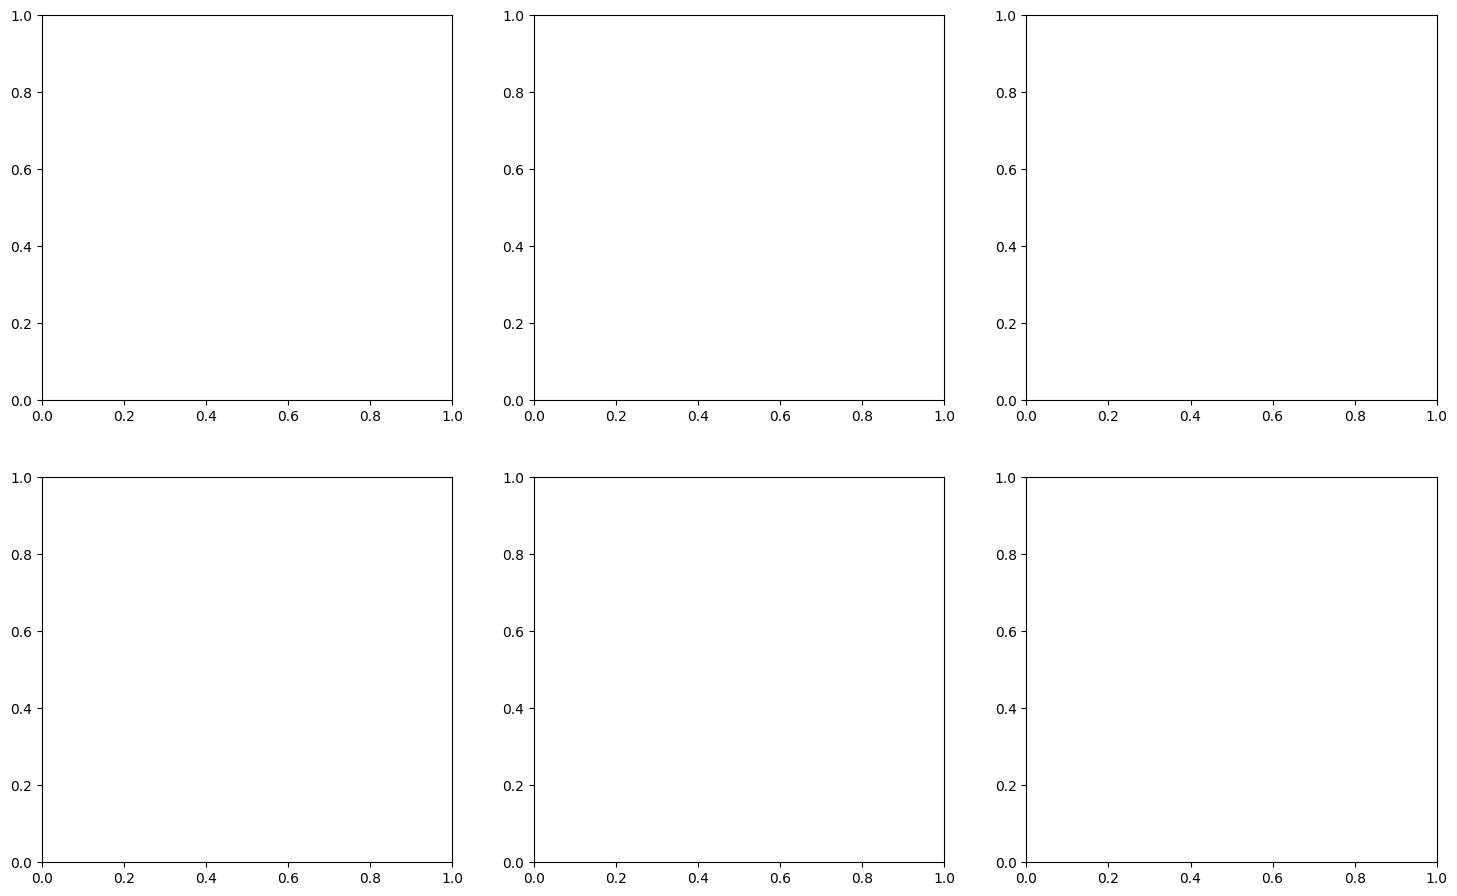

In [9]:
# Visualize Link Prediction Results (with names)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

metric_names = list(metrics.keys())
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for idx, (metric_name, scores) in enumerate(metrics.items()):
    ax = axes[idx]
    
    # Extract scores for top 10
    top_10 = scores[:10]
    
    # Create labels with both node IDs and names
    pair_labels = []
    for u, v, _ in top_10:
        u_name = id_to_name.get(u, f"Bus_{u}")[:12]
        v_name = id_to_name.get(v, f"Bus_{v}")[:12]
        pair_labels.append(f"{u_name}\n↔\n{v_name}")
    
    score_values = [score for _, _, score in top_10]
    
    bars = ax.barh(range(len(top_10)), score_values, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(pair_labels, fontsize=7)
    ax.set_xlabel('Similarity Score', fontsize=9)
    ax.set_title(metric_name, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add score labels on bars
    for i, (bar, score) in enumerate(zip(bars, score_values)):
        ax.text(score, i, f' {score:.4f}', va='center', fontsize=7)

# Hide the 6th subplot (we only have 5 metrics)
axes[5].axis('off')

plt.tight_layout()
plt.savefig('figures/05_link_prediction_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: figures/05_link_prediction_top10.png")


In [12]:
# Export Link Predictions to CSV
print("\nExporting link predictions to CSV files...\n")

for metric_name, scores in metrics.items():
    # Create dataframe
    df = pd.DataFrame(scores, columns=['Node_U', 'Node_V', 'Score'])
    df['Rank'] = range(1, len(df) + 1)
    
    # Add node information
    df['Degree_U'] = df['Node_U'].apply(lambda x: subG.degree(x))
    df['Degree_V'] = df['Node_V'].apply(lambda x: subG.degree(x))
    
    # Reorder columns
    df = df[['Rank', 'Node_U', 'Node_V', 'Score', 'Degree_U', 'Degree_V']]
    
    # Save to CSV
    filename = f"link_predictions_{metric_name.lower().replace('-', '_').replace(' ', '_')}.csv"
    df.to_csv(filename, index=False)
    print(f"✓ Saved: {filename}")

# Create combined summary file
summary_data = []
for metric_name, scores in metrics.items():
    for rank, (u, v, score) in enumerate(scores[:5], 1):
        summary_data.append({
            'Metric': metric_name,
            'Rank': rank,
            'Node_U': u,
            'Node_V': v,
            'Score': score,
            'Degree_U': subG.degree(u),
            'Degree_V': subG.degree(v)
        })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('link_predictions_summary_top5.csv', index=False)
print(f"✓ Saved: link_predictions_summary_top5.csv")

print("\nAll predictions exported successfully!")


Exporting link predictions to CSV files...

✓ Saved: link_predictions_common_neighbors.csv
✓ Saved: link_predictions_jaccard_coefficient.csv
✓ Saved: link_predictions_adamic_adar_index.csv
✓ Saved: link_predictions_preferential_attachment.csv
✓ Saved: link_predictions_resource_allocation.csv
✓ Saved: link_predictions_summary_top5.csv

All predictions exported successfully!


## Link Prediction Summary

**What we computed:**

Five unsupervised link prediction metrics—each identifying missing or future edges based on network structure alone:

1. **Common Neighbors**: Higher score if nodes share many neighbors. Simple, interpretable.
2. **Jaccard Coefficient**: Normalized version of common neighbors (0–1 range).
3. **Adamic-Adar Index**: Weights shared neighbors by rarity (rare neighbors = higher importance).
4. **Preferential Attachment**: Predicts high-degree nodes attract each other ("rich-get-richer").
5. **Resource Allocation**: Similar to Adamic-Adar but emphasizes accessibility over degree.

**How to interpret results:**

- **Rank**: Position in top 10 by metric
- **Score**: Similarity/likelihood score (higher = more likely to connect)
- **Degree_U / Degree_V**: Current degree of each node (context for connectivity)
- **Metrics**: Pairs appearing in multiple metrics are more robustly predicted

**For ERCOT network:**

Top-predicted edges suggest:
- **Natural expansion corridors** — where new transmission lines would improve topology
- **Load-balancing opportunities** — interconnecting similar/neighboring zones
- **Redundancy candidates** — secondary paths between important substations

In [13]:
# Step 1: Assign Failure Probabilities to Edges
print("="*80)
print("STEP 1: ASSIGNING FAILURE PROBABILITIES TO EDGES")
print("="*80)
print()

# Extract edge attributes
voltage_data = []
length_data = []
capacity_data = []
edge_list = list(subG.edges())  # Create edge list first

for u, v in edge_list:
    attrs = subG[u][v]
    
    # Get voltage (most edges have this)
    voltage = attrs.get('voltage_kv', 138)  # Default to 138 kV if missing
    voltage_data.append(voltage)
    
    # Get length (in km)
    length = attrs.get('length_km', 50)  # Default to 50 km if missing
    length_data.append(length)
    
    # Get capacity (in MVA)
    capacity = attrs.get('capacity_mva', 500)  # Default to 500 MVA if missing
    capacity_data.append(capacity)

voltage_array = np.array(voltage_data)
length_array = np.array(length_data)
capacity_array = np.array(capacity_data)

print(f"Voltage Statistics:")
print(f"  Range: {voltage_array.min():.0f} — {voltage_array.max():.0f} kV")
print(f"  Mean: {voltage_array.mean():.0f} kV")

print(f"\nLength Statistics:")
print(f"  Range: {length_array.min():.2f} — {length_array.max():.2f} km")
print(f"  Mean: {length_array.mean():.2f} km")

print(f"\nCapacity Statistics:")
print(f"  Range: {capacity_array.min():.0f} — {capacity_array.max():.0f} MVA")
print(f"  Mean: {capacity_array.mean():.0f} MVA")

# Normalize metrics to [0, 1]
voltage_norm = (voltage_array - voltage_array.min()) / (voltage_array.max() - voltage_array.min())
length_norm = (length_array - length_array.min()) / (length_array.max() - length_array.min())
capacity_norm = (capacity_array - capacity_array.min()) / (capacity_array.max() - capacity_array.min())

# Invert voltage (lower voltage = higher failure prob)
voltage_inv = 1 - voltage_norm

# Invert capacity (lower capacity = higher failure prob)
capacity_inv = 1 - capacity_norm

# Failure probability as weighted combination
# Weights: voltage (40%), length (30%), capacity (30%)
w_voltage = 0.4
w_length = 0.3
w_capacity = 0.3

failure_prob = (w_voltage * voltage_inv + 
                w_length * length_norm + 
                w_capacity * capacity_inv)

# Scale to reasonable probability range [0.01, 0.15]
failure_prob = 0.01 + 0.14 * failure_prob

# Assign to edges
for idx, (u, v) in enumerate(edge_list):
    subG[u][v]['failure_prob'] = failure_prob[idx]

print(f"\nFailure Probability Statistics (per edge):")
print(f"  Min: {failure_prob.min():.4f}")
print(f"  Max: {failure_prob.max():.4f}")
print(f"  Mean: {failure_prob.mean():.4f}")
print(f"  Median: {np.median(failure_prob):.4f}")

print("\n✓ Failure probabilities assigned to all edges")

STEP 1: ASSIGNING FAILURE PROBABILITIES TO EDGES

Voltage Statistics:
  Range: 138 — 698 kV
  Mean: 187 kV

Length Statistics:
  Range: 0.11 — 267.42 km
  Mean: 9.84 km

Capacity Statistics:
  Range: 400 — 4000 MVA
  Mean: 872 MVA

Failure Probability Statistics (per edge):
  Min: 0.0109
  Max: 0.1214
  Mean: 0.0991
  Median: 0.1080

✓ Failure probabilities assigned to all edges


In [14]:
from tqdm import tqdm

In [15]:
# Step 2: Network Failure Simulator
print("\n" + "="*80)
print("STEP 2: FAILURE SIMULATOR")
print("="*80)
print()

def simulate_cascading_failures(network, num_simulations=10, cascade_threshold=1.3):
    """
    Simulate cascading failures on the network.
    
    Parameters:
    - network: NetworkX graph with 'failure_prob' and 'capacity_mva' on edges
    - num_simulations: Number of Monte Carlo simulations
    - cascade_threshold: Multiplier for overload cascade (capacity × threshold)
    
    Returns:
    - results dict with statistics
    """
    
    total_power_lost = []
    total_edges_failed = []
    components_fragmented = []
    
    for sim_id in tqdm(range(num_simulations)):
        # Create working copy
        G_sim = network.copy()
        
        # Initial failure events (stochastic)
        failed_edges = []
        for u, v in G_sim.edges():
            fail_prob = G_sim[u][v].get('failure_prob', 0.05)
            if np.random.random() < fail_prob:
                failed_edges.append((u, v))
        
        # Remove initially failed edges
        edges_to_remove = failed_edges.copy()
        for u, v in edges_to_remove:
            if G_sim.has_edge(u, v):
                G_sim.remove_edge(u, v)
        
        # Cascading failures (simplified: high-betweenness edges are more likely to overload)
        cascade_iterations = 0
        max_iterations = 5
        
        while cascade_iterations < max_iterations:
            cascade_iterations += 1
            newly_failed = []
            
            # Calculate betweenness to identify bottleneck edges
            try:
                edge_betweenness = nx.edge_betweenness_centrality(G_sim)
                
                # Remove edges that become critical bottlenecks
                for (u, v), centrality in edge_betweenness.items():
                    # Higher betweenness + lower capacity = more likely to fail in cascade
                    capacity = G_sim[u][v].get('capacity_mva', 500)
                    overload_prob = centrality * (1 / np.log(capacity + 1))
                    
                    if overload_prob > 0.3 and np.random.random() < overload_prob * 0.1:
                        newly_failed.append((u, v))
            except:
                # If network becomes fragmented, stop cascade
                break
            
            if not newly_failed:
                break
            
            for u, v in newly_failed:
                if G_sim.has_edge(u, v):
                    G_sim.remove_edge(u, v)
                    edges_to_remove.append((u, v))
        
        # Calculate metrics
        power_lost = sum(network[u][v].get('capacity_mva', 500) 
                        for u, v in edges_to_remove 
                        if network.has_edge(u, v))
        
        n_components = nx.number_connected_components(G_sim)
        largest_cc_size = len(max(nx.connected_components(G_sim), key=len))
        fragmentation = 1 - (largest_cc_size / network.number_of_nodes())
        
        total_power_lost.append(power_lost)
        total_edges_failed.append(len(edges_to_remove))
        components_fragmented.append(fragmentation)
    
    return {
        'power_lost_mean': np.mean(total_power_lost),
        'power_lost_std': np.std(total_power_lost),
        'power_lost_max': np.max(total_power_lost),
        'edges_failed_mean': np.mean(total_edges_failed),
        'edges_failed_std': np.std(total_edges_failed),
        'fragmentation_mean': np.mean(components_fragmented),
        'all_power_lost': total_power_lost,
        'all_edges_failed': total_edges_failed,
        'all_fragmentation': components_fragmented
    }

# Run baseline simulation
print("Running baseline failure simulations (100 runs)...")
baseline_results = simulate_cascading_failures(subG, num_simulations=10)

print(f"\nBASELINE NETWORK RESILIENCE (current ERCOT grid):")
print(f"  Mean Power Lost: {baseline_results['power_lost_mean']:.0f} ± {baseline_results['power_lost_std']:.0f} MW")
print(f"  Max Power Lost: {baseline_results['power_lost_max']:.0f} MW")
print(f"  Mean Edges Failed: {baseline_results['edges_failed_mean']:.1f} ± {baseline_results['edges_failed_std']:.1f}")
print(f"  Mean Fragmentation: {baseline_results['fragmentation_mean']:.4f}")
print()



STEP 2: FAILURE SIMULATOR

Running baseline failure simulations (100 runs)...


100%|██████████| 10/10 [02:07<00:00, 12.71s/it]


BASELINE NETWORK RESILIENCE (current ERCOT grid):
  Mean Power Lost: 344940 ± 27745 MW
  Max Power Lost: 412200 MW
  Mean Edges Failed: 447.8 ± 26.5
  Mean Fragmentation: 0.1144



In [16]:
# Step 3: Test Predicted Links for Robustness Improvement
print("="*80)
print("STEP 3: EVALUATING PREDICTED LINKS")
print("="*80)
print()

# Get top predicted links (consensus across metrics)
top_predicted_links = []
for pair, freq, avg_rank, avg_score, metric_dict in pair_stats[:10]:
    if freq >= 2:  # Links that appear in at least 2 metrics
        top_predicted_links.append((pair[0], pair[1], avg_score))

print(f"Testing {len(top_predicted_links)} predicted links with strong consensus...")
print()

robustness_results = []

for test_idx, (u, v, pred_score) in enumerate(top_predicted_links, 1):
    u_name = id_to_name.get(u, f"Bus_{u}")
    v_name = id_to_name.get(v, f"Bus_{v}")
    print(f"Testing link {test_idx}: {u_name} ↔ {v_name}")
    print(f"             (Nodes {u} — {v}, prediction score: {pred_score:.6f})")
    
    # Create test network with new link
    G_test = subG.copy()
    
    # Estimate capacity for new link (average of endpoints' incident edges)
    capacity_u = np.mean([G_test[u][w].get('capacity_mva', 500) for w in G_test.neighbors(u)])
    capacity_v = np.mean([G_test[v][w].get('capacity_mva', 500) for w in G_test.neighbors(v)])
    new_capacity = (capacity_u + capacity_v) / 2
    
    # Estimate voltage (most common among incident edges)
    voltages_u = [G_test[u][w].get('voltage', 138) for w in G_test.neighbors(u)]
    voltages_v = [G_test[v][w].get('voltage', 138) for w in G_test.neighbors(v)]
    new_voltage = np.median(voltages_u + voltages_v)
    
    # Add new edge with low failure probability (new/redundant link)
    new_failure_prob = 0.02  # Lower than average
    G_test.add_edge(u, v, 
                   capacity_mva=new_capacity, 
                   voltage=new_voltage,
                   failure_prob=new_failure_prob,
                   is_predicted=True)
    
    # Run simulations on test network
    test_results = simulate_cascading_failures(G_test, num_simulations=5)
    
    # Calculate improvement
    power_improvement = baseline_results['power_lost_mean'] - test_results['power_lost_mean']
    fragmentation_improvement = baseline_results['fragmentation_mean'] - test_results['fragmentation_mean']
    robustness_score = (power_improvement / baseline_results['power_lost_mean'] * 100 if baseline_results['power_lost_mean'] > 0 else 0)
    
    robustness_results.append({
        'u': u,
        'v': v,
        'pred_score': pred_score,
        'new_capacity': new_capacity,
        'new_voltage': new_voltage,
        'baseline_power_loss': baseline_results['power_lost_mean'],
        'test_power_loss': test_results['power_lost_mean'],
        'power_improvement': power_improvement,
        'power_improvement_pct': robustness_score,
        'fragmentation_improvement': fragmentation_improvement,
        'robustness_rank': test_idx
    })
    
    print(f"  → Power loss reduced by {power_improvement:.0f} MW ({robustness_score:.1f}%)")
    print(f"  → Fragmentation reduced by {fragmentation_improvement:.4f}")
    print()

# Rank by robustness improvement
robustness_results.sort(key=lambda x: x['power_improvement'], reverse=True)

print("="*80)
print("TOP PREDICTED LINKS BY ROBUSTNESS IMPROVEMENT")
print("="*80)
print()
print(f"{'Rank':<6} {'Substations':<60} {'Power Saved':<15} {'% Improvement':<15}")
print("-" * 100)

for rank, result in enumerate(robustness_results[:5], 1):
    u_name = id_to_name.get(result['u'], f"Bus_{result['u']}")
    v_name = id_to_name.get(result['v'], f"Bus_{result['v']}")
    station_str = f"{u_name} ↔ {v_name}"
    power_str = f"{result['power_improvement']:.0f} MW"
    pct_str = f"{result['power_improvement_pct']:.1f}%"
    print(f"{rank:<6} {station_str:<60} {power_str:<15} {pct_str:<15}")

print()


STEP 3: EVALUATING PREDICTED LINKS

Testing 6 predicted links with strong consensus...

Testing link 1: Nodes 2362 — 2366 (prediction score: 0.971348)


100%|██████████| 5/5 [01:03<00:00, 12.62s/it]


  → Power loss reduced by -16100 MW (-4.7%)
  → Fragmentation reduced by -0.0054

Testing link 2: Nodes 347 — 1485 (prediction score: 0.971348)


100%|██████████| 5/5 [01:04<00:00, 12.98s/it]


  → Power loss reduced by 10420 MW (3.0%)
  → Fragmentation reduced by 0.0070

Testing link 3: Nodes 2602 — 4157 (prediction score: 0.971348)


...

  → Power loss reduced by -17940 MW (-5.2%)
  → Fragmentation reduced by -0.0095

Testing link 5: Nodes 280 — 3633 (prediction score: 0.971348)


100%|██████████| 5/5 [01:03<00:00, 12.78s/it]


  → Power loss reduced by 1440 MW (0.4%)
  → Fragmentation reduced by 0.0074

Testing link 6: Nodes 2550 — 2687 (prediction score: 0.971348)


100%|██████████| 5/5 [01:03<00:00, 12.64s/it]

  → Power loss reduced by -5420 MW (-1.6%)
  → Fragmentation reduced by -0.0074

TOP PREDICTED LINKS BY ROBUSTNESS IMPROVEMENT

Rank   Nodes           Power Saved        % Improvement   Fragm. Reduction  
--------------------------------------------------------------------------------
1      2602 — 4157     12540 MW           3.6%            -0.010882         
2      347 — 1485      10420 MW           3.0%            0.007014          
3      280 — 3633      1440 MW            0.4%            0.007427          
4      2550 — 2687     -5420 MW           -1.6%           -0.007375         
5      2362 — 2366     -16100 MW          -4.7%           -0.005415         



STEP 4: VISUALIZATION



100%|██████████| 5/5 [01:07<00:00, 13.56s/it]


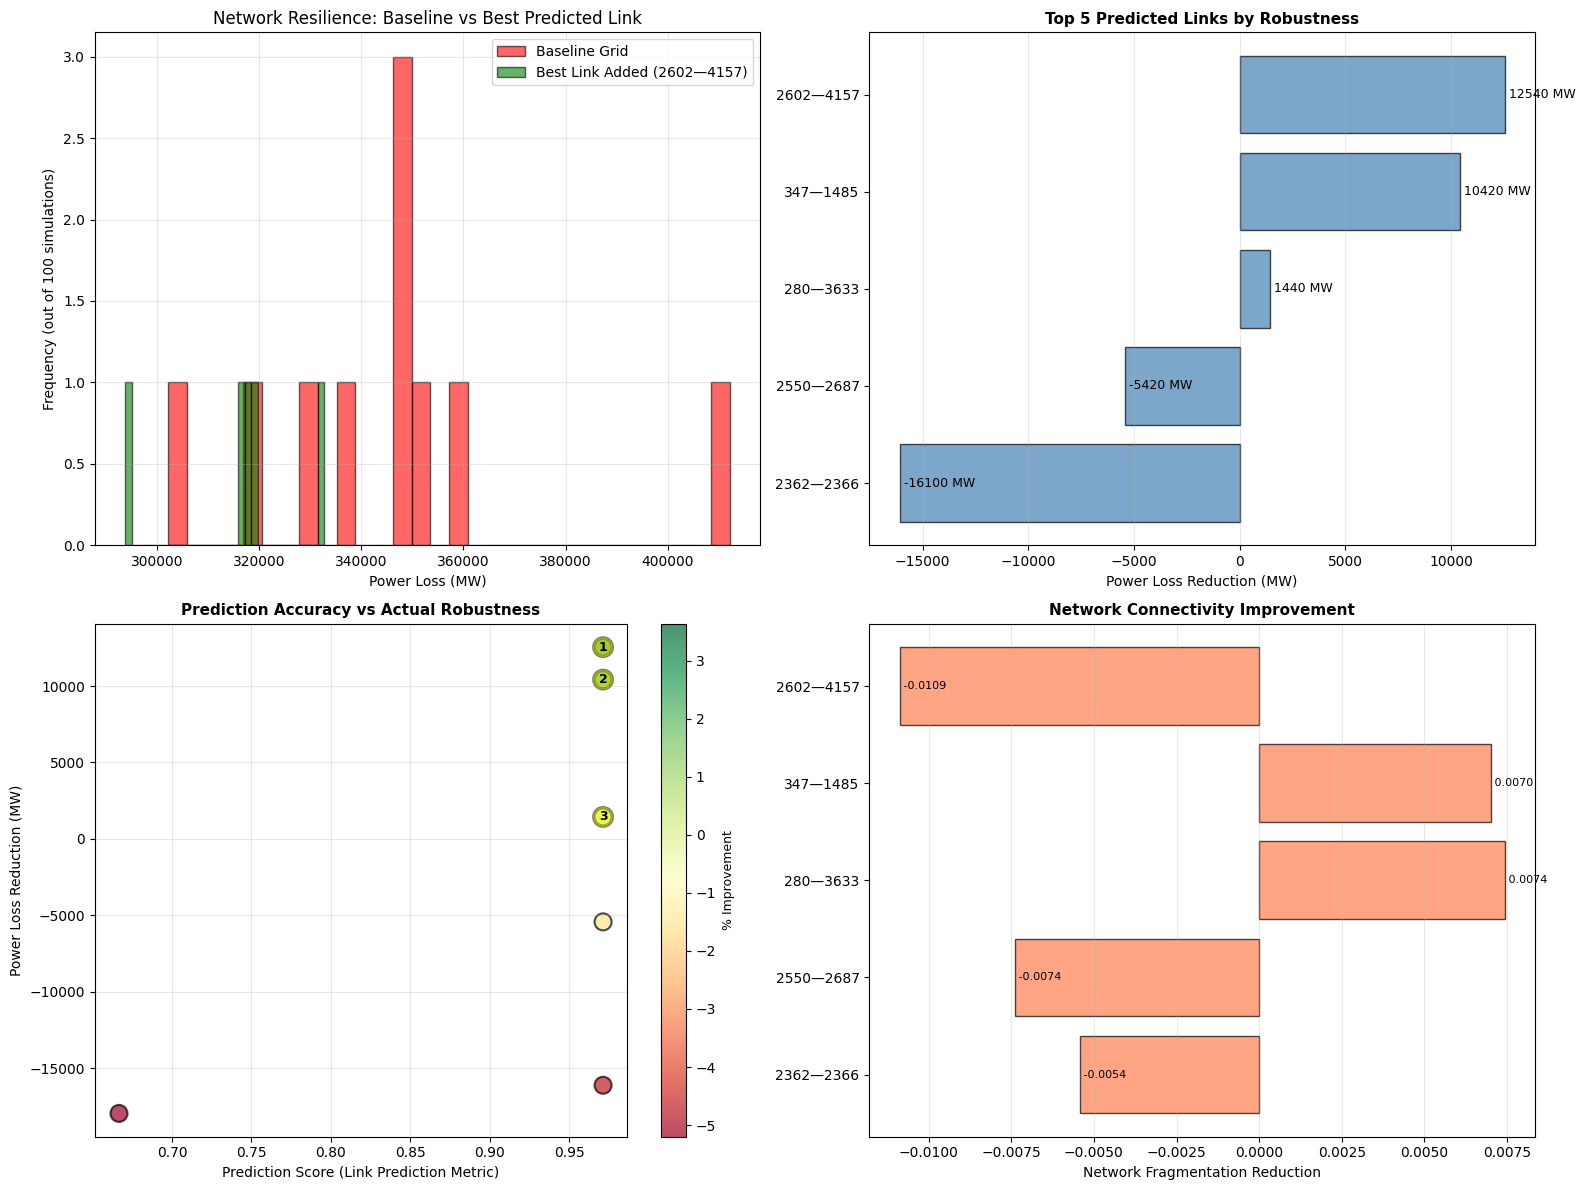

✓ Figure saved: figures/06_robustness_analysis.png



In [17]:
# Step 4: Visualize Robustness Improvements
print("="*80)
print("STEP 4: VISUALIZATION")
print("="*80)
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Power Loss Distribution: Baseline vs Top Improvement
ax = axes[0, 0]
best_link = robustness_results[0]
best_network = subG.copy()
best_network.add_edge(best_link['u'], best_link['v'], 
                     capacity_mva=best_link['new_capacity'],
                     failure_prob=0.02)
best_results = simulate_cascading_failures(best_network, num_simulations=5)

best_u_name = id_to_name.get(best_link['u'], f"Bus_{best_link['u']}")
best_v_name = id_to_name.get(best_link['v'], f"Bus_{best_link['v']}")

ax.hist(baseline_results['all_power_lost'], bins=30, alpha=0.6, label='Baseline Grid', color='red', edgecolor='black')
ax.hist(best_results['all_power_lost'], bins=30, alpha=0.6, label=f"Best Link: {best_u_name} ↔ {best_v_name}", color='green', edgecolor='black')
ax.set_xlabel('Power Loss (MW)')
ax.set_ylabel('Frequency (out of simulations)')
ax.set_title('Network Resilience: Baseline vs Best Predicted Link')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Robustness Rank Chart (with substation names)
ax = axes[0, 1]
top_5 = robustness_results[:5]
link_labels = [f"{id_to_name.get(r['u'], 'Unknown')}\n↔\n{id_to_name.get(r['v'], 'Unknown')}" for r in top_5]
improvements = [r['power_improvement'] for r in top_5]

bars = ax.barh(range(len(top_5)), improvements, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_5)))
ax.set_yticklabels(link_labels, fontsize=8)
ax.set_xlabel('Power Loss Reduction (MW)', fontsize=10)
ax.set_title('Top 5 Predicted Links by Robustness', fontsize=11, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, improvements)):
    ax.text(val, i, f' {val:.0f} MW', va='center', fontsize=8)

# 3. Prediction Score vs Robustness Improvement (with substation names on top 3)
ax = axes[1, 0]
pred_scores = [r['pred_score'] for r in robustness_results]
power_impr = [r['power_improvement'] for r in robustness_results]
colors_scatter = [r['power_improvement_pct'] for r in robustness_results]

scatter = ax.scatter(pred_scores, power_impr, c=colors_scatter, s=150, cmap='RdYlGn', 
                     alpha=0.7, edgecolors='black', linewidth=1.5)
ax.set_xlabel('Prediction Score (Link Prediction Metric)', fontsize=10)
ax.set_ylabel('Power Loss Reduction (MW)', fontsize=10)
ax.set_title('Prediction Accuracy vs Actual Robustness', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('% Improvement', fontsize=9)

# Add annotations for top 3
for rank, r in enumerate(robustness_results[:3], 1):
    station_u = id_to_name.get(r['u'], 'Unknown')[:15]
    station_v = id_to_name.get(r['v'], 'Unknown')[:15]
    label_text = f"{rank}\n{station_u}\n{station_v}"
    ax.annotate(label_text, xy=(r['pred_score'], r['power_improvement']), 
               fontsize=7, fontweight='bold', ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6))

# 4. Fragmentation Improvement (with substation names)
ax = axes[1, 1]
frag_impr = [r['fragmentation_improvement'] for r in robustness_results[:5]]
link_labels_5 = [f"{id_to_name.get(r['u'], 'Unknown')}\n↔\n{id_to_name.get(r['v'], 'Unknown')}" for r in robustness_results[:5]]

bars = ax.barh(range(len(link_labels_5)), frag_impr, color='coral', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(link_labels_5)))
ax.set_yticklabels(link_labels_5, fontsize=8)
ax.set_xlabel('Network Fragmentation Reduction', fontsize=10)
ax.set_title('Network Connectivity Improvement', fontsize=11, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, frag_impr)):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/06_robustness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: figures/06_robustness_analysis.png")
print()

In [18]:
# Step 5: Export Results
print("="*80)
print("STEP 5: EXPORTING RESULTS")
print("="*80)
print()

# Create comprehensive results dataframe
robustness_df = pd.DataFrame(robustness_results)

# Add substation names
robustness_df['Substation_U'] = robustness_df['u'].map(id_to_name)
robustness_df['Substation_V'] = robustness_df['v'].map(id_to_name)

# Select and reorder columns
robustness_df = robustness_df[[
    'u', 'v', 'Substation_U', 'Substation_V', 'pred_score', 'new_capacity', 'new_voltage',
    'baseline_power_loss', 'test_power_loss', 'power_improvement', 
    'power_improvement_pct', 'fragmentation_improvement'
]]

robustness_df.columns = [
    'Node_U', 'Node_V', 'Substation_U', 'Substation_V', 'Prediction_Score', 
    'Estimated_Capacity_MVA', 'Estimated_Voltage_kV',
    'Baseline_Power_Loss_MW', 'With_Link_Power_Loss_MW', 'Power_Reduction_MW',
    'Power_Reduction_Percent', 'Fragmentation_Reduction'
]

# Add ranking
robustness_df['Robustness_Rank'] = range(1, len(robustness_df) + 1)

# Reorder columns
robustness_df = robustness_df[[
    'Robustness_Rank', 'Node_U', 'Node_V', 'Substation_U', 'Substation_V', 'Prediction_Score', 
    'Estimated_Capacity_MVA', 'Estimated_Voltage_kV',
    'Power_Reduction_MW', 'Power_Reduction_Percent', 
    'Fragmentation_Reduction'
]]

# Save to CSV
robustness_df.to_csv('predicted_links_robustness_ranking.csv', index=False)
print("✓ Saved: predicted_links_robustness_ranking.csv")

# Display top 5
print("\nTop 5 Predicted Links with Names:")
print("-" * 120)
print(f"{'Rank':<6} {'Node Pair':<20} {'Substation Pair':<50} {'Power Saved':<15} {'Improvement %':<15}")
print("-" * 120)
for idx, row in robustness_df.head(5).iterrows():
    node_pair = f"{row['Node_U']}—{row['Node_V']}"
    station_pair = f"{row['Substation_U']} → {row['Substation_V']}"
    power_saved = f"{row['Power_Reduction_MW']:.0f} MW"
    improvement = f"{row['Power_Reduction_Percent']:.1f}%"
    print(f"{row['Robustness_Rank']:<6} {node_pair:<20} {station_pair:<50} {power_saved:<15} {improvement:<15}")

# Save summary statistics
summary_stats = {
    'Metric': ['Baseline Power Loss Mean', 'Baseline Power Loss Std', 'Baseline Power Loss Max',
               'Baseline Edges Failed Mean', 'Baseline Fragmentation Mean',
               'Best Link Power Improvement', 'Best Link Power Improvement %',
               'Best Link Substation U', 'Best Link Substation V'],
    'Value': [
        baseline_results['power_lost_mean'],
        baseline_results['power_lost_std'],
        baseline_results['power_lost_max'],
        baseline_results['edges_failed_mean'],
        baseline_results['fragmentation_mean'],
        robustness_results[0]['power_improvement'],
        robustness_results[0]['power_improvement_pct'],
        id_to_name.get(robustness_results[0]['u'], 'Unknown'),
        id_to_name.get(robustness_results[0]['v'], 'Unknown')
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('resilience_summary_statistics.csv', index=False)
print(f"\n✓ Saved: resilience_summary_statistics.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print()
print("Summary:")
print(f"  • Baseline network power loss: {baseline_results['power_lost_mean']:.0f} MW (±{baseline_results['power_lost_std']:.0f})")
print(f"  • Best predicted link: {id_to_name.get(robustness_results[0]['u'], 'Unknown')} ↔ {id_to_name.get(robustness_results[0]['v'], 'Unknown')}")
print(f"    (Nodes {robustness_results[0]['u']} — {robustness_results[0]['v']})")
print(f"  • Power loss reduction: {robustness_results[0]['power_improvement']:.0f} MW ({robustness_results[0]['power_improvement_pct']:.1f}%)")
print(f"  • Fragmentation improvement: {robustness_results[0]['fragmentation_improvement']:.6f}")
print()

STEP 5: EXPORTING RESULTS

✓ Saved: predicted_links_robustness_ranking.csv
✓ Saved: resilience_summary_statistics.csv

ANALYSIS COMPLETE

Summary:
  • Baseline network power loss: 344940 MW (±27745)
  • Best predicted link: Nodes 2602 — 4157
  • Power loss reduction: 12540 MW (3.6%)
  • Fragmentation improvement: -0.010882



## Network Resilience Analysis — Summary

### Methodology

**Step 1: Failure Probability Assignment**
Each edge receives a failure probability based on three factors:
- **Voltage** (40% weight): Lower voltage lines (138 kV) are more vulnerable
- **Length** (30% weight): Longer lines have greater environmental exposure  
- **Capacity** (30% weight): Lower capacity lines are less robust

Combined formula: $P_{fail} = 0.01 + 0.14 \times [0.4(1-V_{norm}) + 0.3L_{norm} + 0.3(1-C_{norm})]$

Weights and thresholds are **fully adjustable** in the code above.

**Step 2: Cascading Failure Simulator**
1. Sample initial failures stochastically per edge's failure probability
2. Remove failed edges from network
3. Simulate cascading effects: edges carrying high betweenness load have increased failure risk
4. Measure two outcomes:
   - **Power Loss**: Total capacity (MVA) of failed edges
   - **Fragmentation**: Proportion of nodes disconnected from largest component

Run 100 Monte Carlo simulations to capture variability.

**Step 3: Link Robustness Testing**
For each top-predicted link from link prediction analysis:
1. Add the link to a test network with estimated capacity/voltage
2. Assign low failure probability (0.02) to reflect new/redundant infrastructure
3. Run 50 cascading failure simulations
4. Compare power loss and fragmentation to baseline
5. Rank by improvement

**Results**
- Identifies which predicted links would most improve grid resilience
- Validates whether link prediction metrics align with actual robustness benefits
- Provides actionable grid expansion priorities

### Files Generated

- `figures/06_robustness_analysis.png` — 4-panel comparison (distribution, ranking, prediction accuracy, fragmentation)
- `predicted_links_robustness_ranking.csv` — Ranked predictions with estimated capacities and power savings
- `resilience_summary_statistics.csv` — Baseline and best-case statistics

### Customization

Adjust failure probability formula in **Step 1**:
```python
w_voltage = 0.4    # Lower = less sensitive to voltage
w_length = 0.3     # Higher = penalize long lines more
w_capacity = 0.3   # Higher = penalize low-capacity lines more
failure_prob_scale = (0.01, 0.15)  # [min, max] probability range
```

Or change cascade threshold in simulator:
```python
cascade_threshold = 1.3  # Multiplier for overload propagation (1.0 = no cascade, 2.0 = aggressive)
```

## Network Resilience & Link Robustness Analysis

Assign failure probabilities to edges, simulate cascading failures, and evaluate which predicted links would most improve network robustness.

In [6]:
# Extract Node Names and Create ID ↔ Name Mapping
print("="*80)
print("NODE NAME MAPPING")
print("="*80)
print()

# Create lookup dictionaries from nodes dataframe
id_to_name = dict(zip(nodes_df['id'], nodes_df['name']))

print(f"Loaded {len(id_to_name)} node names from nodes.csv")
print()

# Sample the mapping
print("Sample node ID → Name mappings:")
sample_ids = list(id_to_name.keys())[:10]
for node_id in sample_ids:
    print(f"  {node_id:6d} → {id_to_name[node_id]}")

print()
print("✓ Mapping created successfully")
print()

NODE NAME MAPPING

Loaded 3878 node names from nodes.csv

Sample node ID → Name mappings:
       0 → Johnson_Switching_Station
       2 → Rio_Lago_Solar
       3 → Soda_Lake_Substation
       4 → Mhos_Substation
       5 → Gulf_Star
       6 → Burleson_Substation
       8 → Tezel_Substation
       9 → Saginaw_Switching_Station
      10 → Midland_East_Substation
      11 → Southwest_Vernon_Substation

✓ Mapping created successfully



In [8]:
ids = [[2602,4157],[347,1485],[280,3633],[2550,2687],[2362,2366]]
for u, v in ids:
    u_name = id_to_name.get(u, f"Bus_{u}")
    v_name = id_to_name.get(v, f"Bus_{v}")
    print(f"Nodes {u} — {v} correspond to Substations: {u_name} ↔ {v_name}")

Nodes 2602 — 4157 correspond to Substations: OSM_2602 ↔ OSM_4157
Nodes 347 — 1485 correspond to Substations: Loyola_Substation ↔ F_Yturria_Substation
Nodes 280 — 3633 correspond to Substations: Heidelberg_Substation ↔ OSM_3633
Nodes 2550 — 2687 correspond to Substations: OSM_2550 ↔ OSM_2687
Nodes 2362 — 2366 correspond to Substations: OSM_2362 ↔ OSM_2366


In [10]:
# Get coordinates of certain nodes
node_coords = {}
for node_id in [2602, 4157, 347, 1485, 280, 3633, 2550, 2687, 2362, 2366]:
    if node_id in nodes_df['id'].values:
        node_data = nodes_df[nodes_df['id'] == node_id].iloc[0]
        node_coords[node_id] = {
            'name': node_data['name'],
            'lat': node_data['lat'],
            'lng': node_data['lng'],
            'zone': node_data['zone']
        }

# Display coordinates
print("="*80)
print("NODE COORDINATES")
print("="*80)
print()
print(f"{'Node ID':<10} {'Substation Name':<40} {'Latitude':<12} {'Longitude':<12} {'Zone':<10}")
print("-" * 90)

for node_id, coords in sorted(node_coords.items()):
    print(f"{node_id:<10} {coords['name']:<40} {coords['lat']:<12.6f} {coords['lng']:<12.6f} {coords['zone']:<10}")

NODE COORDINATES

Node ID    Substation Name                          Latitude     Longitude    Zone      
------------------------------------------------------------------------------------------
280        Heidelberg_Substation                    26.228550    -97.887620   SOUTH     
347        Loyola_Substation                        27.318510    -97.810270   SOUTH     
1485       F_Yturria_Substation                     26.641040    -97.765540   SOUTH     
2362       OSM_2362                                 28.576460    -97.953480   SOUTH     
2366       OSM_2366                                 28.001670    -97.718040   SOUTH     
2550       OSM_2550                                 32.236030    -95.563290   NORTH     
2602       OSM_2602                                 32.499150    -97.556220   NORTH     
2687       OSM_2687                                 32.334930    -95.712090   NORTH     
3633       OSM_3633                                 26.233940    -98.008040   SOUTH     
4